**PROYECTO: HOUSE PRICE PREDICTION "A Real Estate Dataset for Regression and Price Estimation"**

https://www.kaggle.com/datasets/raviiyadavv/house-price-predecition

* Este dataset tiene información de diferentes casas o viviendas con carácteristicas como superficie, número de dormitorios, baños, plazas de aparcamiento, estado del mobiliario y otros detalles relacionados con la propiedad. El objetivo principal es predecir los precios de las viviendas basándose en estas características.





**Introducción**
* Cargar Datos
* Exploración 
* Distribución
* Limpieza

In [ ]:
# Librerías importadas
import pandas as pd
import numpy as np

In [ ]:
# Cargar el set de datos de las casas
house_df = pd.read_csv("dataset_2.csv")
house_df.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [ ]:
house_df.info() # Información sobre cada columna con sus datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1091 non-null   float64
 1   Rooms          1091 non-null   float64
 2   Build_Year     1124 non-null   int64  
 3   Location       1124 non-null   object 
 4   Street_Type    1124 non-null   object 
 5   Furnishing     1091 non-null   object 
 6   Property_Type  1124 non-null   object 
 7   Has_Pool       1124 non-null   object 
 8   Price          1124 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 79.2+ KB


In [6]:
house_df.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,1091.000000,1091.000000,1124.000000,1.124000e+03
mean,2237.479473,4.568286,2005.080071,6.082015e+05
std,731.097828,1.678155,11.708876,1.431958e+05
min,700.000000,2.000000,1985.000000,2.486400e+05
25%,1834.022964,3.000000,1995.000000,5.161948e+05
50%,2201.545784,5.000000,2005.000000,6.025410e+05
75%,2576.139355,6.000000,2015.000000,6.895785e+05
max,10267.124330,7.000000,2024.000000,2.071402e+06


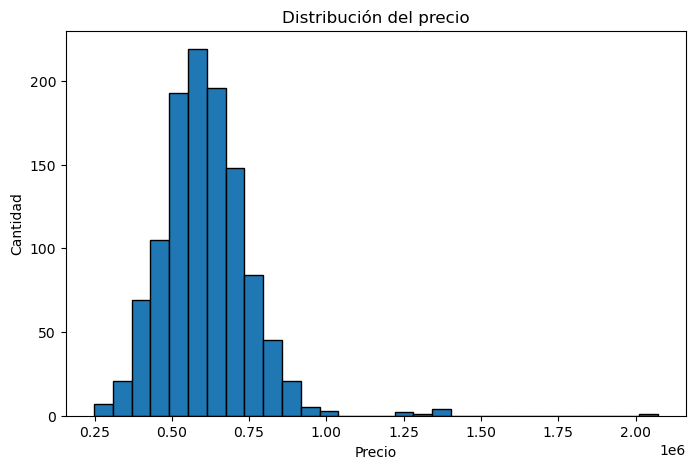

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(house_df["Price"],
         bins=30,
         edgecolor="black")

plt.title("Distribución del precio")

plt.xlabel("Precio")

plt.ylabel("Cantidad")

plt.show()

In [ ]:
house_df.isnull().sum() 

Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64

Dado que tenemos valores nulos en las columnas "Area_SqFT", "Rooms" y "Furnishing" es que es importante rellenar los nulos con la mediana si son valores númericos y con la moda si son valores categóricas.


In [15]:
house_df["Area_SqFt"] = house_df["Area_SqFt"].fillna(house_df["Area_SqFt"].median())
house_df["Rooms"] = house_df["Rooms"].fillna(house_df["Rooms"].median())

In [16]:
house_df["Furnishing"] = house_df["Furnishing"].fillna(house_df["Furnishing"].mode()[0])

In [53]:
house_df.isnull().sum()

Area_SqFt        0
Rooms            0
Build_Year       0
Location         0
Street_Type      0
Furnishing       0
Property_Type    0
Has_Pool         0
Price            0
dtype: int64

**Entrenamiento**

Aqui se entrena el modelo para predecir los costos de cada vivienda, para luego analizar cual modelo es mejor para el dataset.


In [ ]:
X = house_df.drop("Price", axis=1) # Variable Independiente
y = house_df["Price"] # Variable Dependiente

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder 

# Para convertir las columnas de texto por números

cat_cols = ["Location","Street_Type","Furnishing","Property_Type","Has_Pool"]
num_cols = ["Area_SqFt","Rooms","Build_Year"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

modelo = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor( # Partimos probando el modelo de RandomForest
        n_estimators=100,
        random_state=42
    ))
])

modelo.fit(X_train, y_train)
predicciones = modelo.predict(X_test)

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predicciones)
rmse = np.sqrt(mean_squared_error(y_test, predicciones))
r2 = r2_score(y_test, predicciones)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

error_porcentaje = (mae / y.mean()) * 100

print(f"Error promedio: {error_porcentaje:.2f}%")

MAE : 34371.37
RMSE: 43692.83
R²  : 0.9097
Error promedio: 5.65%


**Como resultado preliminar, tenemos un buen R^2, un MAE Y RMSE alto debido a la escala de los precios, pero que con con el error promedio se puede traducir mejor.**

Ahora se procedirá a realizar de nuevo el entrenamiento pero usando otros modelos de regresión.

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


# Diccionario con los modelos
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Recorrer cada modelo
for nombre, modelo in modelos.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    # Entrenar
    pipeline.fit(X_train, y_train)

    # Predecir
    pred = pipeline.predict(X_test)

    # Métricas
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print(f"\nModelo: {nombre}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")


Modelo: Regresión Lineal
MAE : 20089.17
RMSE: 34258.79
R²  : 0.9445

Modelo: Árbol de Decisión
MAE : 56219.19
RMSE: 81033.50
R²  : 0.6893

Modelo: Random Forest
MAE : 34371.37
RMSE: 43692.83
R²  : 0.9097


**Gráficos Obtenidos**

En general, se logra apreciar que el mejor modelo sin duda es Regresión Lineal, sin embargo este es debido a la correlación positiva que tiene en la columna "Area_sqFt"

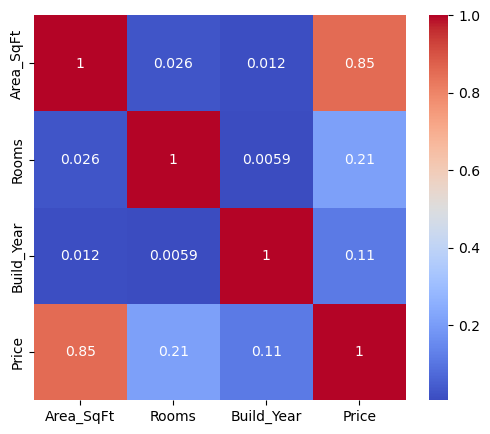

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = house_df_copy.corr(numeric_only=True)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

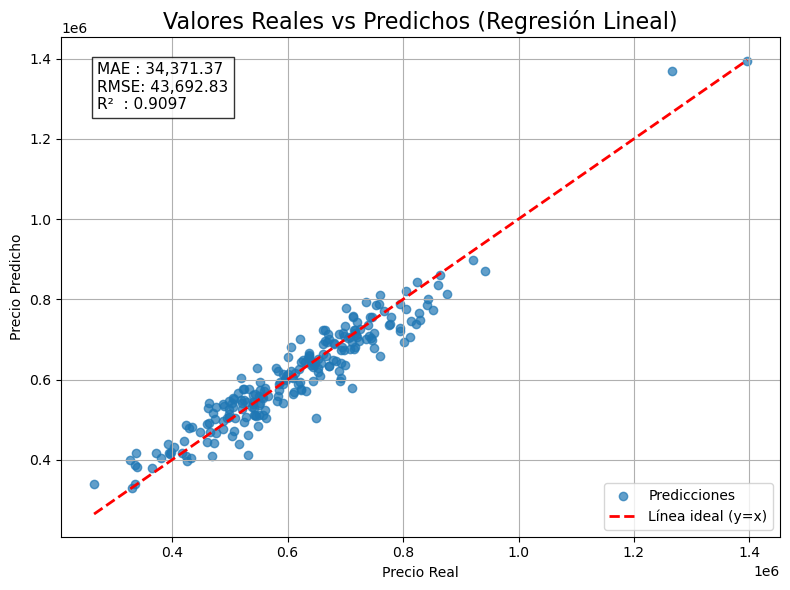

In [56]:
# Métricas
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

# Figura
plt.figure(figsize=(8,6))

# Scatter de valores reales vs predichos
plt.scatter(y_test, pred, alpha=0.7, label="Predicciones")

# Línea ideal (y = x)
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         'r--',
         linewidth=2,
         label='Línea ideal (y=x)')

# Título y etiquetas
plt.title("Valores Reales vs Predichos (Regresión Lineal)", fontsize=16)
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")

# Cuadro con métricas
texto = (
    f"MAE : {mae:,.2f}\n"
    f"RMSE: {rmse:,.2f}\n"
    f"R²  : {r2:.4f}"
)

plt.text(
    0.05,
    0.95,
    texto,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


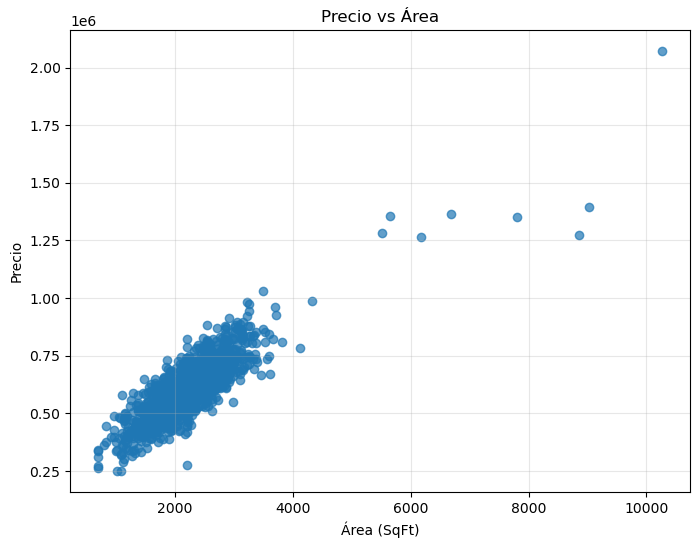

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(house_df_copy["Area_SqFt"], house_df_copy["Price"], alpha=0.7)

plt.xlabel("Área (SqFt)")
plt.ylabel("Precio")
plt.title("Precio vs Área")

plt.grid(alpha=0.3)
plt.show()

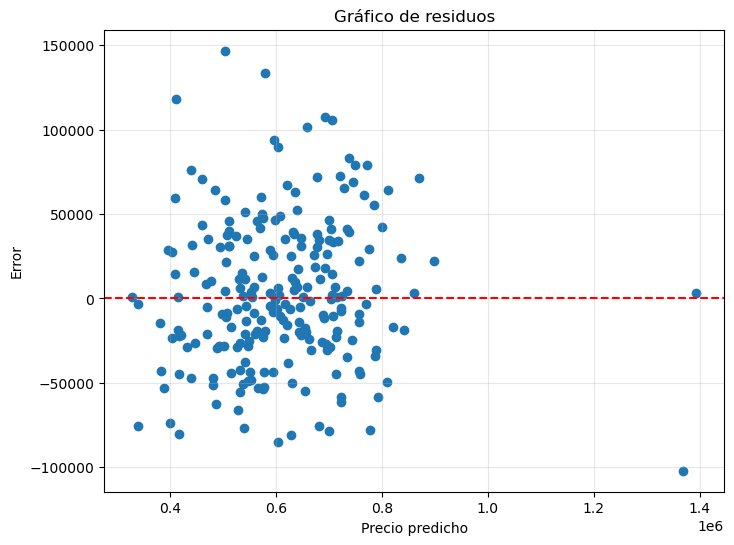

In [37]:
residuos = y_test - pred

plt.figure(figsize=(8,6))

plt.scatter(pred, residuos)

plt.axhline(0,
            color="red",
            linestyle="--")

plt.xlabel("Precio predicho")
plt.ylabel("Error")
plt.title("Gráfico de residuos")

plt.grid(alpha=0.3)

plt.show()

<Axes: xlabel='Has_Pool', ylabel='Price'>

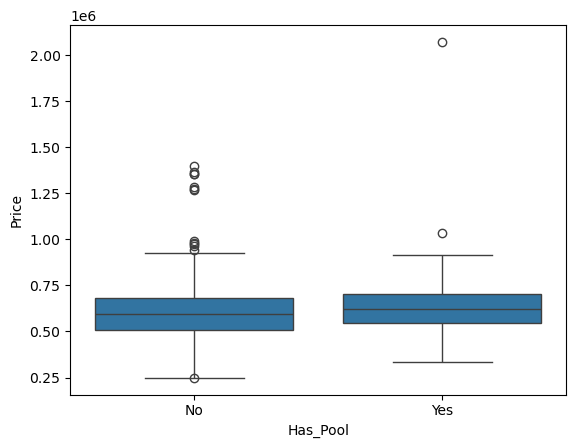

In [45]:
sns.boxplot(x="Has_Pool", y="Price", data=house_df_copy)

<Axes: xlabel='Location', ylabel='Price'>

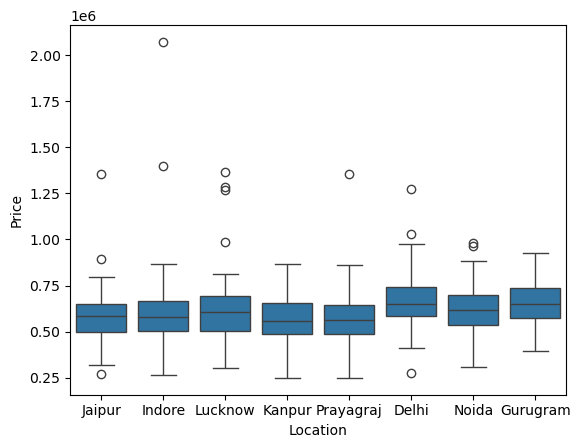

In [43]:
sns.boxplot(x="Location", y="Price", data=house_df_copy)

In [46]:
comparacion = X_test.copy()

comparacion["Precio Real"] = y_test
comparacion["Precio Predicho"] = pipeline.predict(X_test)
comparacion["Error"] = abs(
    comparacion["Precio Real"] -
    comparacion["Precio Predicho"]
)

comparacion.head(10)

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Precio Real,Precio Predicho,Error
1088,3164.257141,7.0,2001,Lucknow,Residential Lane,Unfurnished,Apartment,No,700394.0,778388.68692,77994.68692
896,1663.449410,6.0,2015,Delhi,Highway Facing,Semi-Furnished,Duplex,No,630978.0,570830.99000,60147.01000
739,1890.986845,3.0,1998,Gurugram,Main Road,Unfurnished,Independent House,No,540206.0,561321.22000,21115.22000
140,1754.073244,3.0,2016,Gurugram,Main Road,Semi-Furnished,Apartment,Yes,557654.0,511860.61000,45793.39000
1041,2089.889310,4.0,2010,Prayagraj,Gated Society,Semi-Furnished,Independent House,No,597366.0,607588.77000,10222.77000
527,1350.592456,3.0,1999,Gurugram,Highway Facing,Furnished,Apartment,No,423088.0,408864.79000,14223.21000
812,2461.573640,2.0,2007,Jaipur,Corner Plot,Semi-Furnished,Villa,Yes,667439.0,694643.33000,27204.33000
481,1687.337989,6.0,2021,Jaipur,Corner Plot,Semi-Furnished,Independent House,No,524124.0,549160.26000,25036.26000
1117,1801.115978,7.0,2010,Jaipur,Gated Society,Unfurnished,Duplex,No,586093.0,593861.55000,7768.55000
949,2732.238624,6.0,2006,Lucknow,Residential Lane,Semi-Furnished,Independent House,No,698404.0,708644.09000,10240.09000


In [58]:
# Seleccionar una vivienda del conjunto de prueba
indice = 5

casa = X_test.iloc[[indice]]

# Precio real
precio_real = y_test.iloc[indice]

# Precio predicho
precio_predicho = pipeline.predict(casa)[0]

# Error
error = abs(precio_real - precio_predicho)
error_porcentaje = (error / precio_real) * 100

print("="*50)
print("        PREDICCIÓN DE UNA VIVIENDA")
print("="*50)

print(f"Área (SqFt)       : {casa['Area_SqFt'].values[0]}")
print(f"Habitaciones      : {int(casa['Rooms'].values[0])}")
print(f"Año construcción  : {int(casa['Build_Year'].values[0])}")
print(f"Ubicación         : {casa['Location'].values[0]}")
print(f"Tipo de calle     : {casa['Street_Type'].values[0]}")
print(f"Amueblado         : {casa['Furnishing'].values[0]}")
print(f"Tipo propiedad    : {casa['Property_Type'].values[0]}")
print(f"Piscina           : {casa['Has_Pool'].values[0]}")

print("\n" + "-"*50)

print(f" Precio real      : ${precio_real:,.2f}")
print(f" Precio predicho  : ${precio_predicho:,.2f}")
print(f" Error absoluto   : ${error:,.2f}")
print(f" Error porcentual : {error_porcentaje:.2f}%")

        PREDICCIÓN DE UNA VIVIENDA
Área (SqFt)       : 1350.592456
Habitaciones      : 3
Año construcción  : 1999
Ubicación         : Gurugram
Tipo de calle     : Highway Facing
Amueblado         : Furnished
Tipo propiedad    : Apartment
Piscina           : No

--------------------------------------------------
 Precio real      : $423,088.00
 Precio predicho  : $408,864.79
 Error absoluto   : $14,223.21
 Error porcentual : 3.36%


**Conclusión**

Durante este proyecto se desarrolló un modelo de Machine Learning para predecir el precio de viviendas a partir de características como el área, número de habitaciones, año de construcción, ubicación, tipo de calle, nivel de amueblado, tipo de propiedad y disponibilidad de piscina.

Como parte del proceso, se realizó la limpieza de los datos, el tratamiento de valores faltantes, la codificación de variables categóricas mediante One-Hot Encoding y la división del conjunto de datos en entrenamiento y prueba. Posteriormente, se comparó el rendimiento de tres modelos de regresión: Regresión Lineal, Árbol de Decisión y Random Forest.

Los resultados mostraron que la Regresión Lineal fue el modelo con mejor desempeño, obteniendo un MAE de 20089, un RMSE de 34259 y un R² de 0.9445, lo que indica que el modelo explica aproximadamente el 94.45 % de la variabilidad del precio de las viviendas. Estos resultados sugieren que las variables disponibles presentan una relación mayoritariamente lineal con el precio, permitiendo obtener predicciones precisas.

Como trabajo futuro, sería interesante evaluar modelos adicionales como XGBoost, LightGBM o CatBoost, además de realizar una optimización de hiperparámetros mediante GridSearchCV o RandomizedSearchCV para determinar si es posible mejorar aún más el rendimiento predictivo.

Habilidades demostradas

✓ Limpieza y preprocesamiento de datos
✓ Tratamiento de valores faltantes
✓ Codificación de variables categóricas
✓ Construcción de Pipelines en Scikit-Learn
✓ Comparación de modelos de Machine Learning
✓ Evaluación con métricas MAE, RMSE y R²
✓ Visualización de datos con Matplotlib y Seaborn
✓ Predicción e interpretación de resultados